# NYC Airbnb Data Workflow Analysis
**Name:** Rashila Adhikari
**Dataset:** NYC Airbnb Listings (2019)  

### Project Overview
This project demonstrates a complete, reproducible data science workflow using Python. 
I am cleaning and exploring the NYC Airbnb dataset to identify pricing trends and 
borough-specific patterns, providing a foundation for future predictive AI modeling.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset (Make sure the .csv file is in the same folder as this notebook!)
df = pd.read_csv("AB_NYC_2019.csv")

# Display the first 5 rows to verify it worked
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [2]:
def clean_missing_values(df):
    """
    Handles missing values specifically for the Airbnb dataset.
    Fills 'reviews_per_month' with 0 and removes rows with missing 'name' or 'host_name'.
    """
    df_copy = df.copy()
    # Filling numerical NaNs with 0 where appropriate
    df_copy['reviews_per_month'] = df_copy['reviews_per_month'].fillna(0)
    # Dropping rows with essential missing strings
    df_copy = df_copy.dropna(subset=['name', 'host_name'])
    return df_copy

def remove_price_outliers(df):
    """
    Filters out rows where price is 0 (invalid) and removes extreme 
    outliers using the 95th percentile to keep the analysis focused.
    """
    # Keep prices between $1 and the 95th percentile
    upper_limit = df['price'].quantile(0.95)
    df_filtered = df[(df['price'] > 0) & (df['price'] <= upper_limit)]
    return df_filtered

# Apply the functions
df_cleaned = clean_missing_values(df)
df_final = remove_price_outliers(df_cleaned)

# Task 5 Validation: Check the new shape
print(f"Original rows: {df.shape[0]} | Cleaned rows: {df_final.shape[0]}")
df_final.head()

Original rows: 48895 | Cleaned rows: 46407


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,0.00,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [3]:
def analyze_listings_by_borough(df):
    """
    Groups the data by borough (neighbourhood_group) to calculate 
    the average price, total listings, and average availability.
    """
    # Grouping data and calculating statistics
    eda_summary = df.groupby('neighbourhood_group').agg({
        'price': 'mean',
        'id': 'count',
        'availability_365': 'mean'
    }).rename(columns={
        'price': 'Average Price',
        'id': 'Listing Count',
        'availability_365': 'Avg Availability'
    })
    
    # Sorting by price for better readability
    return eda_summary.sort_values(by='Average Price', ascending=False)

# Execute the function and display results
borough_stats = analyze_listings_by_borough(df_final)
print("--- NYC Airbnb Borough Analysis ---")
borough_stats

--- NYC Airbnb Borough Analysis ---


,Average Price,Listing Count,Avg Availability
neighbourhood_group,,,
Manhattan,149.652612,19851,106.583850
Brooklyn,107.580488,19537,98.631878
Queens,89.803546,5584,143.378940
Staten Island,89.235616,365,199.893151
Bronx,78.155140,1070,164.395327


/tmp/ipykernel_730/2535227852.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='neighbourhood_group', y='price', data=df_final, palette='Set2')


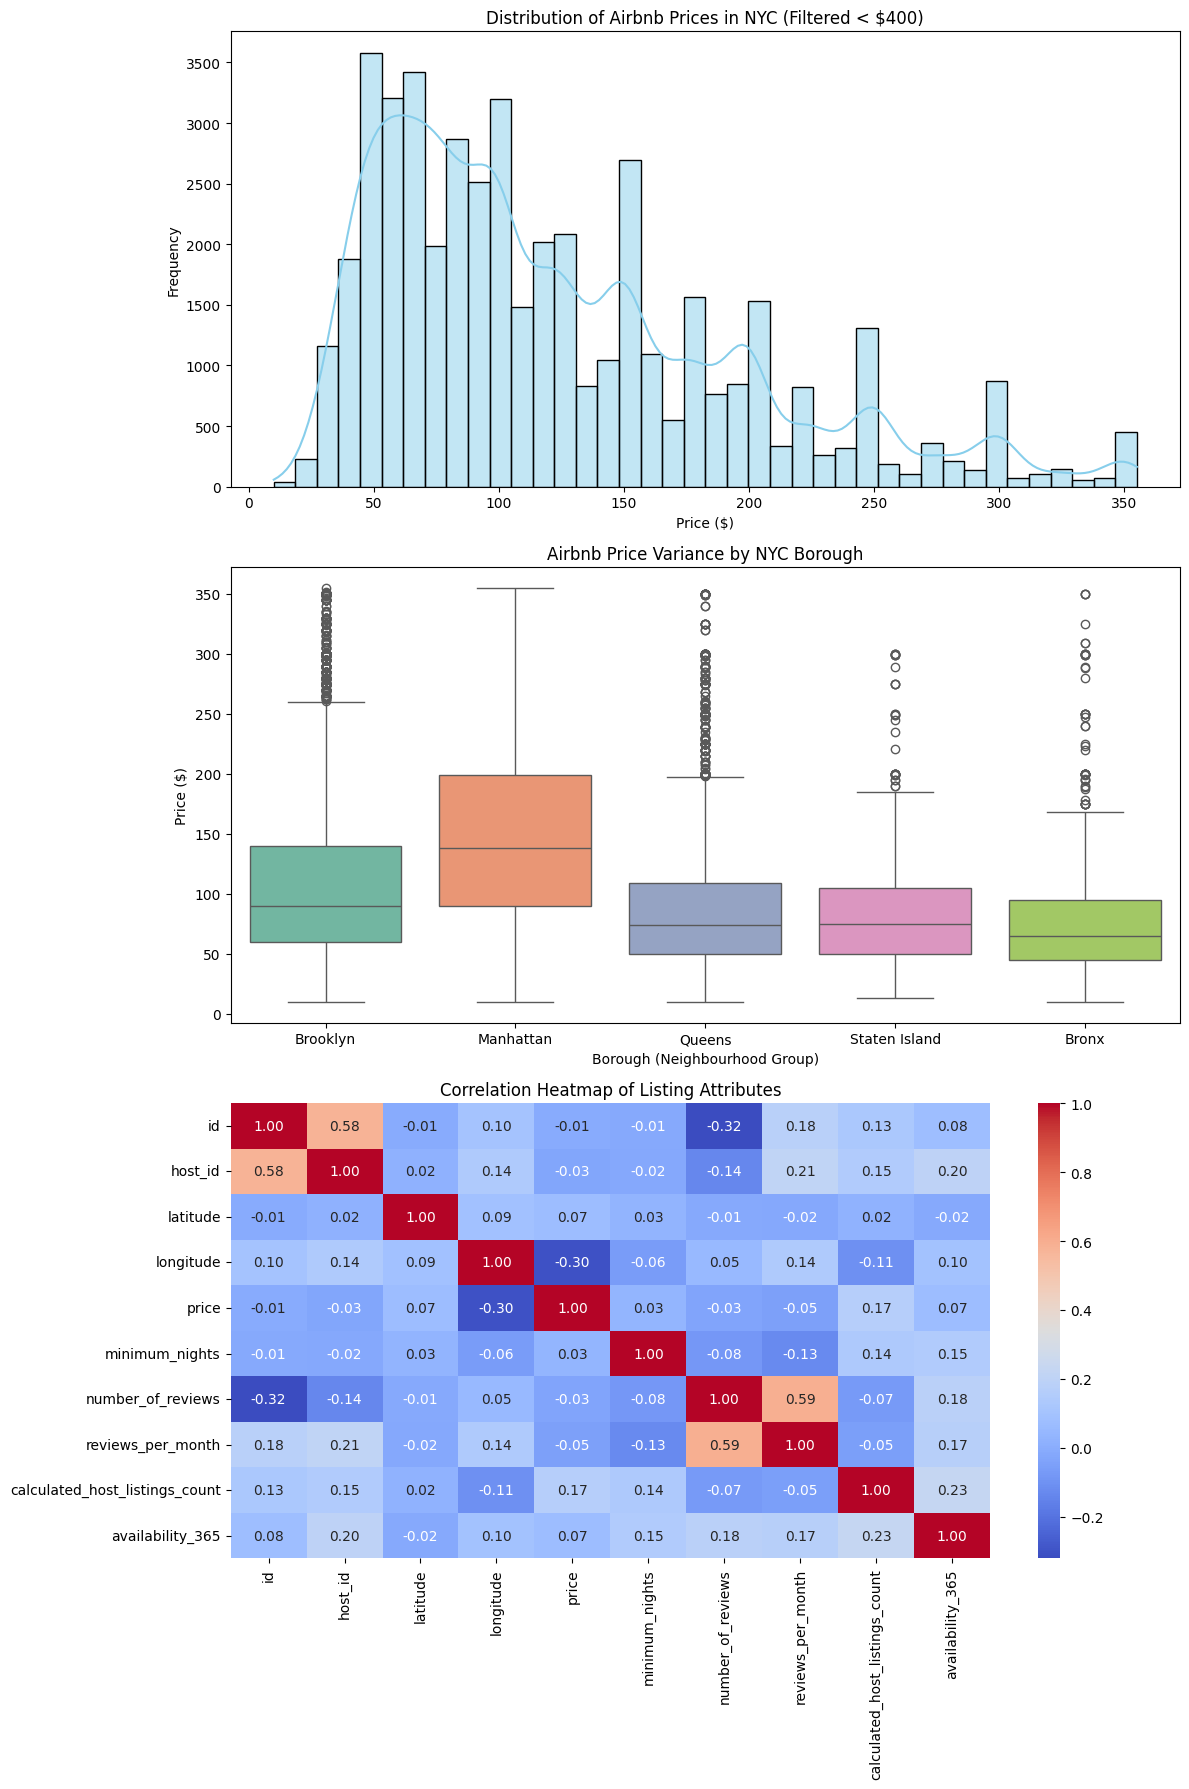

In [4]:
# Create a figure with a specific size
plt.figure(figsize=(12, 18))

# --- Visualization 1: Price Distribution (Histogram) ---
plt.subplot(3, 1, 1)
sns.histplot(df_final['price'], bins=40, kde=True, color='skyblue')
plt.title('Distribution of Airbnb Prices in NYC (Filtered < $400)')
plt.xlabel('Price ($)')
plt.ylabel('Frequency')

# --- Visualization 2: Price by Borough (Boxplot) ---
plt.subplot(3, 1, 2)
sns.boxplot(x='neighbourhood_group', y='price', data=df_final, palette='Set2')
plt.title('Airbnb Price Variance by NYC Borough')
plt.xlabel('Borough (Neighbourhood Group)')
plt.ylabel('Price ($)')

# --- Visualization 3: Correlation Heatmap ---
plt.subplot(3, 1, 3)
# Selecting only numerical columns for correlation
numeric_cols = df_final.select_dtypes(include=[np.number])
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Listing Attributes')

# Adjust layout to prevent overlapping
plt.tight_layout()
plt.show()

## Summary and Interpretation of Findings

### Key Insights
* **Borough Pricing:** Manhattan exhibits the highest average price and the greatest price variance, while the Bronx remains the most affordable borough for travelers.
* **Market Skewness:** The price distribution is heavily right-skewed, indicating that while luxury listings exist, the majority of the NYC market consists of budget-to-mid-range options.
* **Feature Correlation:** There is a weak correlation between price and the number of reviews, suggesting that price is driven more by location and room type than by listing popularity or guest volume.

### Limitations and Assumptions
* **Temporal Constraints:** This analysis uses 2019 data and does not reflect current post-pandemic market fluctuations or new NYC short-term rental regulations.
* **Outlier Handling:** By removing listings above the 95th percentile, extreme luxury penthouses were excluded to provide a more representative view of the average user experience.